## Key Insights
Total sales = $2297200.86
Sales by Region = $286397.02
Data span over 4 years (2014 - 2017) 

Profits for:  
2014: $49543.97 while sales is $484247.50  
2015: $61618.60 while sales is $470532.51  
2016: $81795.17 while sales is $609205.60  
2017: $93439.27 while sales is $733215.26  

Profits by Region:  
West: $108418.45  
East: $91522.78  
Central: $39706.36  
South: $46749.43  

Top Products per Category:  
Technology:  
- Canon imageCLASS 2200 Advanced Copier: $25199.93  
- Hewlett Packard LaserJet 3310 Copier: $6983.88  
- Canon PC1060 Personal Laser Copier: $4570.93  

Office Supplies:  
- Fellowes PB500 Electric Punch Plastic Comb Bin: $7753.04  
- Ibico EPK-21 Electric Binding System: $3345.28  
- Honeywell Enviracaire Portable HEPA Air Cleane: $3247.02  

Furniture:  
- Hon Deluxe Fabric Upholstered Stacking Chairs: $1927.44  
- Global Deluxe High-Back Manager's Chair: $1558.59  
- Hon Pagoda Stacking Chairs: $1540.70  

Discounts increase and profitability is not linear

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
duckdb.sql("""
SELECT *
FROM read_csv_auto('../data/superstore.csv')
LIMIT 10
""").df()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.86,7,0.00,14.17
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.28,4,0.00,1.97
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.15,6,0.20,90.72
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.50,3,0.20,5.78
9,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.90,5,0.00,34.47


In [4]:
con = duckdb.connect()

con.execute("""
CREATE VIEW superstore AS
SELECT *
FROM read_csv_auto('../data/superstore.csv')
""")

So dont have to use FROM read_csv_auto

In [8]:
con.execute("""
SELECT *
FROM superstore
LIMIT 1
""").df()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91


In [100]:
con.execute("""
SELECT  SUM("Sales") AS total_sales,
        SUM("Profit") AS total_profit
FROM superstore
""").df()
            

,total_sales,total_profit
0,2297200.86,286397.02


In [77]:
con.execute("""
SELECT MIN("Order Date") AS first_order_date,
       MAX("Order Date") AS last_order_date
FROM superstore
""").df()

,first_order_date,last_order_date
0,2014-01-03,2017-12-30


So this is total sales for start of 2014 until end of 2017

In [78]:
con.execute("""
SELECT Region,
        COUNT(*) AS orders,
        Sum(Sales) AS total_sales,
        SUM(Quantity) AS total_quantity,
        SUM(Profit) AS total_profit
FROM superstore
GROUP BY Region
ORDER BY orders DESC
""").df()

,Region,orders,total_sales,total_quantity,total_profit
0,West,3203,725457.82,12266.00,108418.45
1,East,2848,678781.24,10618.00,91522.78
2,Central,2323,501239.89,8780.00,39706.36
3,South,1620,391721.91,6209.00,46749.43


I noticed that there are regions, so firstly i checked what regions are available, then i see how many rows (orders) is for each Region (using GROUP BY)
Then I want to see the correlation between number of orders and total profit. I also do want to see the total profit for each region
I find it weird that even though Central got more orders than South so i pull up the total sales and total quantity for each region
After reviewing the numbers, my initial assumption is that South sells more high profit items compared to Central; next i need to determine which high profit item South is selling

In [79]:
con.execute("""
SELECT Category,
       SUM(Sales) AS total_sales,
       SUM(Quantity) AS total_quantity,
       SUM(Profit) AS total_profit,
       SUM(Profit) / SUM(Sales) AS profit_margin
FROM superstore
GROUP BY Category
ORDER BY profit_margin DESC
""").df()

,Category,total_sales,total_quantity,total_profit,profit_margin
0,Technology,836154.03,6939.00,145454.95,0.17
1,Office Supplies,719047.03,22906.00,122490.80,0.17
2,Furniture,741999.80,8028.00,18451.27,0.02


In [88]:
con.execute(""" 
        SELECT "Product Name", 
        SUM(Profit) AS total_profit 
FROM superstore 
WHERE "Category" = 'Furniture'
GROUP BY "Product Name" 
ORDER BY total_profit DESC 
LIMIT 5 
""").df()

,Product Name,total_profit
0,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",1927.44
1,Global Deluxe High-Back Manager's Chair,1558.59
2,Hon Pagoda Stacking Chairs,1540.70
3,Hon 4070 Series Pagoda Armless Upholstered Sta...,1388.63
4,Office Star - Professional Matrix Back Chair w...,1305.65


In [89]:
con.execute(""" 
        SELECT "Product Name", 
        SUM(Profit) AS total_profit 
FROM superstore 
WHERE "Category" = 'Technology'
GROUP BY "Product Name" 
ORDER BY total_profit DESC 
LIMIT 5 
""").df()

,Product Name,total_profit
0,Canon imageCLASS 2200 Advanced Copier,25199.93
1,Hewlett Packard LaserJet 3310 Copier,6983.88
2,Canon PC1060 Personal Laser Copier,4570.93
3,HP Designjet T520 Inkjet Large Format Printer ...,4094.98
4,Ativa V4110MDD Micro-Cut Shredder,3772.95


In [90]:
con.execute(""" 
        SELECT "Product Name", 
        SUM(Profit) AS total_profit 
FROM superstore 
WHERE "Category" = 'Office Supplies'
GROUP BY "Product Name" 
ORDER BY total_profit DESC 
LIMIT 5 
""").df()

,Product Name,total_profit
0,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.04
1,Ibico EPK-21 Electric Binding System,3345.28
2,Honeywell Enviracaire Portable HEPA Air Cleane...,3247.02
3,Fellowes PB300 Plastic Comb Binding Machine,2518.06
4,Ibico Ibimaster 300 Manual Binding System,2318.34


Result of Region triggered curiosity as to why one can have more orders but less profit. Lets search what category is available and each of their profitibility. After knowing which Category is more profitable, we have a look at which is the most profitable product for each category. Seeing the total profit for the product, it is proven that furnitures are less profitable based on their profit margin as well as top 5 most profitable items

In [91]:
con.execute("""
SELECT Discount,
       AVG(Profit) AS avg_profit
FROM superstore
GROUP BY Discount
ORDER BY Discount
""").df()

,Discount,avg_profit
0,0.00,66.90
1,0.10,96.06
2,0.15,27.29
3,0.20,24.70
4,0.30,-45.68
5,0.32,-88.56
6,0.40,-111.93
7,0.45,-226.65
8,0.50,-310.70
9,0.60,-43.08


This means that discount increase does not mean that profit will drop linearly. Will be explored on

In [9]:
con.execute("""
SELECT YEAR("Order Date") AS year,
        SUM("Sales") AS total_sales,
        SUM("Profit") AS total_profit
FROM superstore
GROUP BY year
ORDER BY total_profit DESC
""").df()

,year,total_sales,total_profit
0,2017,733215.26,93439.27
1,2016,609205.60,81795.17
2,2015,470532.51,61618.60
3,2014,484247.50,49543.97


2017 is the most profitable year, 2016 is second. 2015 is third despite lower sales compared to 2014, meaning more high profit item is sold in 2015 compared to 2014

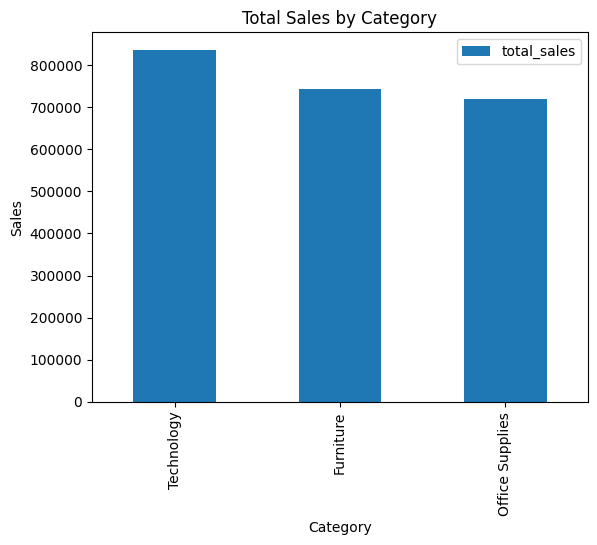

In [14]:
df = con.execute("""
SELECT Category,
       SUM(Sales) AS total_sales
FROM superstore
GROUP BY Category
ORDER BY total_sales DESC
""").df()

df.plot(x="Category", y="total_sales", kind="bar")

plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

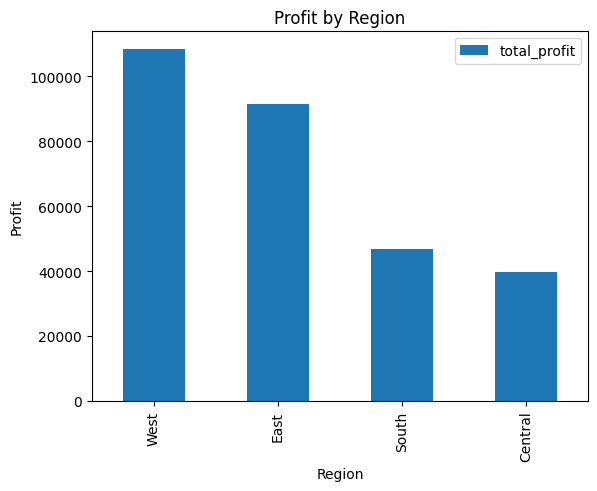

In [18]:
df = con.execute("""
SELECT Region,
       SUM(Profit) AS total_profit
FROM superstore
GROUP BY Region
ORDER BY total_profit DESC
""").df()

df.plot(x="Region", y="total_profit", kind="bar")

plt.title("Profit by Region")
plt.ylabel("Profit")
plt.show()

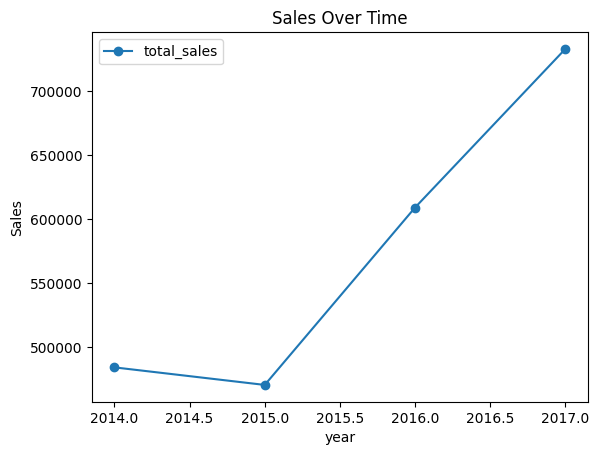

In [10]:
df = con.execute("""
SELECT YEAR("Order Date") AS year,
       SUM(Sales) AS total_sales
FROM superstore
GROUP BY year
ORDER BY year
""").df()

df.plot(x="year", y="total_sales", kind="line", marker="o")

plt.title("Sales Over Time")
plt.ylabel("Sales")
plt.show()

In [18]:
con.execute("""
SELECT *
FROM superstore
LIMIT 1
""").df()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91


In [14]:
con.execute("""
SELECT State,
       SUM(Sales) AS total_sales
FROM superstore
GROUP BY State
ORDER BY total_sales DESC
LIMIT 10
""").df()

,State,total_sales
0,California,457687.63
1,New York,310876.27
2,Texas,170188.05
3,Washington,138641.27
4,Pennsylvania,116511.91
5,Florida,89473.71
6,Illinois,80166.10
7,Ohio,78258.14
8,Michigan,76269.61
9,Virginia,70636.72


In [15]:
con.execute("""
SELECT City,
       SUM(Sales) AS total_sales
FROM superstore
GROUP BY City
ORDER BY total_sales DESC
LIMIT 10
""").df()

,City,total_sales
0,New York City,256368.16
1,Los Angeles,175851.34
2,Seattle,119540.74
3,San Francisco,112669.09
4,Philadelphia,109077.01
5,Houston,64504.76
6,Chicago,48539.54
7,San Diego,47521.03
8,Jacksonville,44713.18
9,Springfield,43054.34


In [17]:
con.execute("""
SELECT Region,
       SUM(Profit) / SUM(Sales) AS profit_margin
FROM superstore
GROUP BY Region
ORDER BY profit_margin
LIMIT 10
""").df()

,Region,profit_margin
0,Central,0.08
1,South,0.12
2,East,0.13
3,West,0.15


In [50]:
con.execute("""
SELECT "Product Name",
       SUM("Profit") AS profit,
       SUM("Sales" ) AS sales
FROM superstore
GROUP BY "Product Name"
ORDER BY profit DESC
LIMIT 10
""").df()   

,Product Name,profit,sales
0,Canon imageCLASS 2200 Advanced Copier,25199.93,61599.82
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.04,27453.38
2,Hewlett Packard LaserJet 3310 Copier,6983.88,18839.69
3,Canon PC1060 Personal Laser Copier,4570.93,11619.83
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.98,18374.90
5,Ativa V4110MDD Micro-Cut Shredder,3772.95,7699.89
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.97,14299.89
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.28,9367.29
8,Ibico EPK-21 Electric Binding System,3345.28,15875.92
9,Zebra ZM400 Thermal Label Printer,3343.54,6965.70


In [26]:
con.execute("""
SELECT Category,
FROM superstore
group by Category
""").df()

,Category
0,Technology
1,Furniture
2,Office Supplies


In [36]:
con.execute("""
DESCRIBE superstore
""").df()

,column_name,column_type,null,key,default,extra
0,Row ID,BIGINT,YES,None,None,None
1,Order ID,VARCHAR,YES,None,None,None
2,Order Date,DATE,YES,None,None,None
3,Ship Date,DATE,YES,None,None,None
4,Ship Mode,VARCHAR,YES,None,None,None
5,Customer ID,VARCHAR,YES,None,None,None
6,Customer Name,VARCHAR,YES,None,None,None
7,Segment,VARCHAR,YES,None,None,None
8,Country,VARCHAR,YES,None,None,None
9,City,VARCHAR,YES,None,None,None


In [37]:
con.execute("""
SELECT Month("Order Date") AS month,
       SUM(Sales) AS total_sales
FROM superstore
Group BY month
ORDER BY total_sales DESC
""").df()

,month,total_sales
0,11,352461.07
1,12,325293.50
2,9,307649.95
3,3,205005.49
4,10,200322.98
5,8,159044.06
6,5,155028.81
7,6,152718.68
8,7,147238.10
9,4,137762.13


In [47]:
con.execute("""
SELECT "Sub-Category",
       SUM("Sales") AS total_sales
FROM superstore
WHERE Month("Order Date") = 11
GROUP BY "Sub-Category"
ORDER BY total_sales DESC

""").df()

,Sub-Category,total_sales
0,Phones,56220.93
1,Chairs,47760.01
2,Storage,37023.15
3,Machines,33807.30
4,Tables,33182.48
5,Accessories,25956.73
6,Bookcases,23561.02
7,Binders,20857.65
8,Appliances,18969.93
9,Furnishings,16782.54
